# LLE and Kernel PCA

## LLE

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import MDS, Isomap, TSNE
from sklearn.decomposition import KernelPCA

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:


X_swiss, t = make_swiss_roll(n_samples = 1000, noise = 0.2, random_state = 42)
lle = LocallyLinearEmbedding(n_components= 2, n_neighbors=10, random_state= 42)
X_unrolled = lle.fit_transform(X_swiss)

In [15]:
from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

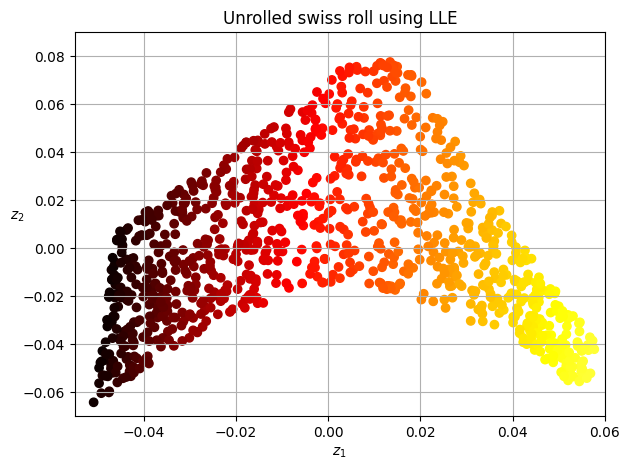

In [17]:
plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap = darker_hot)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation = 0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)
plt.title("Unrolled swiss roll using LLE")
save_fig("lle_unrolling_plot")

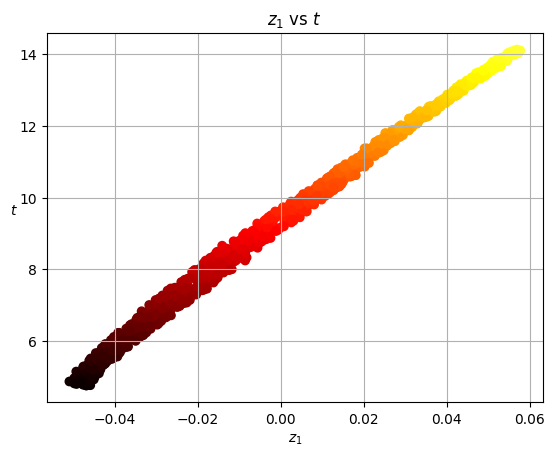

In [18]:
plt.scatter(X_unrolled[:, 0], t, c=t, cmap= darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$t$", rotation=0)
plt.title("$z_1$ vs $t$")
plt.grid(True)

In [20]:
mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

In [23]:
isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

In [25]:
tsne = TSNE(n_components=2, init='random', learning_rate="auto", random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

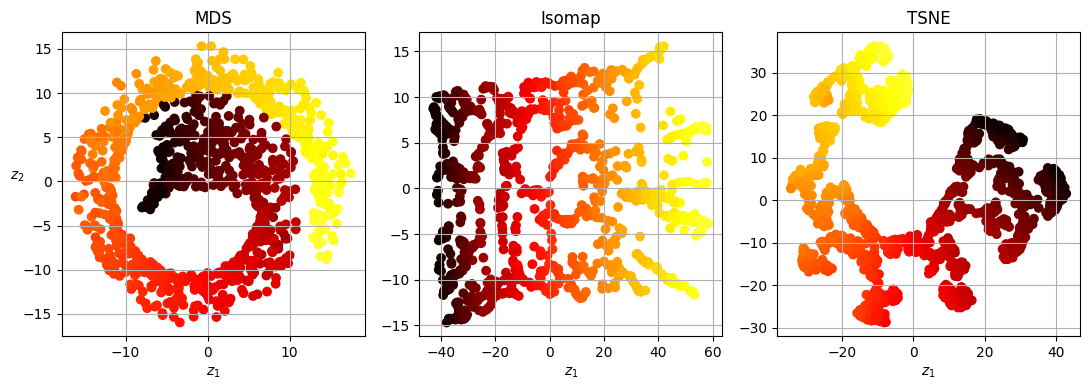

In [26]:
titles = ["MDS", "Isomap", "TSNE"]

plt.figure(figsize=(11, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles, (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation =0)
    plt.grid(True)

save_fig("other_dim_reduction_plot")

## Kernel PCA

In [29]:
rbf_pca = KernelPCA(n_components=2, kernel = "rbf", gamma= 0.04, random_state=42)
X_reduced_rbf = rbf_pca.fit_transform(X_swiss)

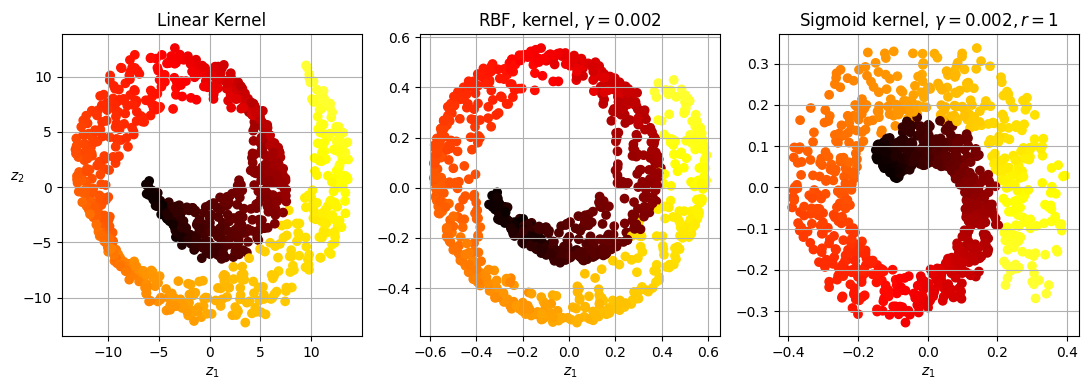

In [30]:
lin_pca = KernelPCA(kernel= "linear")
rbf_pca = KernelPCA(kernel= "rbf", gamma=0.002)
sig_pca = KernelPCA(kernel = "sigmoid", gamma=0.002, coef0=1)

kernel_pcas = ((lin_pca, "Linear Kernel"),
              (rbf_pca, rf"RBF, kernel, $\gamma={rbf_pca.gamma}$"),
              (sig_pca, rf"Sigmoid kernel, $\gamma = {sig_pca.gamma}, r={sig_pca.coef0}$"))

plt.figure(figsize=(11, 4))
for idx, (kpca, title) in enumerate(kernel_pcas):
    kpca.n_components = 2
    kpca.random_state = 42
    X_reduced = kpca.fit_transform(X_swiss)

    plt.subplot(1, 3, idx + 1)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if idx == 0:
        plt.ylabel("$z_2$", rotation = 0)
    plt.grid()

save_fig("Linear PCA, RBF PCA and Sigmoid PCA")

## Kernel PCA